## Simplification des canaux

Dans ce notebook, les canaux ne sont pas modélisés physiquement.

👉 On utilise des valeurs constantes simples pour :

- faciliter la compréhension
- visualiser le rôle des variables
- se concentrer sur l'algorithme d'optimisation

Les canaux seront remplacés par un modèle réaliste ultérieurement.

## Paramètres du système

- M : nombre d'antennes AP
- N : nombre d'éléments RIS
- K : nombre d'utilisateurs

In [466]:
import numpy as np

M = 16
N = 100
K = 1

sigma2 = 1e-3

omega = np.ones(K)

P_T_dB = 15 # ?? pourquoi pas
P_T = 10**(P_T_dB/10)

# vecteurs des puissances ?
W = (np.random.randn(M, K) + 1j*np.random.randn(M, K)) / np.sqrt(2)
W = W / np.linalg.norm(W) #* np.sqrt(P_T)



## Modélisation des canaux

On modélise les canaux comme des variables gaussiennes complexes (Rayleigh fading) pondérées par un path-loss dépendant de la distance.

Pour chaque lien :

$$
h \sim \mathcal{CN}(0, \beta(d))
\quad \Longleftrightarrow \quad
h = \sqrt{\beta(d)} \cdot g,\; g \sim \mathcal{CN}(0,1)
$$

où :

- $\beta(d) = d^{-\alpha}$ est l'atténuation (path-loss)
- $\alpha$ est l'exposant de propagation

On construit ensuite :

- $h_{d,k}$ : canal direct AP → utilisateur k
- $h_{r,k}$ : canal RIS → utilisateur k
- $G$ : canal AP → RIS
- $H_{r,k} = \mathrm{diag}(h_{r,k}^*)\, G$

In [467]:
alpha = 2
C0 = 10**(-30/10)
gamma_rician = 10

def path_loss(d):
    return d**(-alpha)

def rayleigh(shape):
    return (np.random.randn(*shape) + 1j*np.random.randn(*shape)) / np.sqrt(2)

def channel(shape, d):
    return np.sqrt(path_loss(d)) * rayleigh(shape)

# distances identiques
d_ap_user = 30
d_ris_user = 30
d_ap_ris = 30

# matrice de phase RIS
phi = 2 * np.pi * np.random.rand(N)
Theta = np.diag(np.exp(1j * phi))


hd = []
Hr = []
"""
# canal AP -> RIS (commun)
G = channel((N, M), d_ap_ris)



for k in range(K):
    hd_k = channel((M,), d_ap_user)
    hr_k = channel((N,), d_ris_user)

    # canal RIS corrigé
    Hr_k = np.diag(np.conj(hr_k)) @ Theta @ G

    hd.append(hd_k)
    Hr.append(Hr_k)"""

def generate_rician_channel(N_rx, N_tx, dist, C0, beta, gamma):
    path_loss = np.sqrt(C0 * (dist**-beta)) 
    #path_loss = 1 #en mettant ça, on retrouve à peu près les courbes du papier
    # LoS component
    phi_t = np.random.uniform(0, 2*np.pi)
    phi_r = np.random.uniform(0, 2*np.pi)
    # Ensure these are (N, 1) and (1, N)
    ar = np.exp(1j * np.pi * np.sin(phi_r) * np.arange(N_rx)).reshape(-1, 1) / np.sqrt(N_rx)
    at = np.exp(1j * np.pi * np.sin(phi_t) * np.arange(N_tx)).reshape(-1, 1) / np.sqrt(N_tx)
    H_LoS = ar @ at.conj().T
    # NLoS component
    H_NLoS = (np.random.randn(N_rx, N_tx) + 1j*np.random.randn(N_rx, N_tx)) / np.sqrt(2)
    # Combine
    H = path_loss * (np.sqrt(gamma/(1+gamma)) * H_LoS + np.sqrt(1/(1+gamma)) * H_NLoS)
    return H

# Initialisation des listes pour stocker les canaux
hd = []
Hr = []

# 1. Conversion de gamma_rician en linéaire (si ce n'est pas déjà fait)
# IMPORTANT: La formule sqrt(g/(1+g)) nécessite une valeur linéaire.
gamma_lin = 10**(gamma_rician / 10)

# 2. Canal BS -> RIS (Commun à l'utilisateur)
# Taille (N, M) : N éléments RIS, M antennes BS
G = generate_rician_channel(N, M, d_ap_ris, C0, alpha, gamma_lin)

# 3. Canaux spécifiques à l'utilisateur k=0
# Canal Direct BS -> User : Taille (1, M)
# Canal Direct BS -> User : on ajoute .flatten() ou [0, :]
hd_k = generate_rician_channel(1, M, d_ap_user, C0, alpha, gamma_lin).flatten()

# Canal RIS -> User : on ajoute .flatten()
hr_k = generate_rician_channel(1, N, d_ris_user, C0, alpha, gamma_lin).flatten()

# 4. Calcul du canal réfléchi composé : Hr_k = diag(hr_k^H) * Theta * G
# Note : on utilise .flatten() sur hr_k pour que np.diag crée une matrice (N, N)
Hr_k_composed = np.diag(hr_k.conj().T.flatten()) @ G #@ Theta on l'enlève cf. p 3 du papier

# 5. Stockage
hd.append(hd_k)
Hr.append(Hr_k_composed)

## Vecteur de phase du RIS

Chaque élément du RIS modifie la phase du signal :

$$
\theta_n = e^{j\phi_n}, \quad |\theta_n| = 1
$$

In [468]:
theta = np.exp(1j * 2*np.pi*np.random.rand(N))

# Calcul du canal global

In [469]:
def compute_hk(hd, Hr, theta):
    hk = []
    for k in range(K):
        h = hd[k] + Hr[k].conj().T @ theta
        hk.append(h)
    return hk

## Mise à jour de $w_k$ (WMMSE)

On utilise les équations complètes du papier :

- $\chi_k$
- $\kappa_k$
- mise à jour de $w_k$

In [470]:
def update_W(hk, W): # ??? d'où sort ce calcul ???
    chi = np.zeros(K, dtype=complex)
    kappa = np.zeros(K, dtype=complex)
    
    # =========================
    # calcul chi
    # =========================
    for k in range(K):
        num = hk[k].conj() @ W[:, k]
        
        denom = 0
        for i in range(K):
            denom += np.abs(hk[k].conj() @ W[:, i])**2
        
        denom += sigma2
        
        chi[k] = num / denom
    
    # =========================
    # calcul kappa
    # =========================
    for k in range(K):
        val = hk[k].conj() @ W[:, k]
        kappa[k] = 1 / (1 - np.conj(chi[k]) * val)
    
    # =========================
    # matrice A
    # =========================
    A = np.zeros((M, M), dtype=complex)
    
    for i in range(K):
        hi = hk[i].reshape(-1,1)
        A += omega[i] * np.abs(chi[i])**2 * kappa[i] * (hi @ hi.conj().T)
    
    A += np.eye(M) #I*lambda ??
    A_inv = np.linalg.inv(A)
    
    # =========================
    # update W
    # =========================
    W_new = np.zeros((M, K), dtype=complex)
    
    for k in range(K):
        W_new[:, k] = (
            omega[k] * chi[k] * kappa[k] * (A_inv @ hk[k])
        )
    
    return W_new

## Décomposition du signal

On définit :

$$
a_{i,k} = H_{r,k} w_i
$$

$$
b_{i,k} = h_{d,k}^H w_i
$$

Cela permet de séparer :
- la contribution du RIS
- la contribution directe

In [471]:
def compute_a_b(Hr, hd, W):
    a = {}
    b = {}
    
    for i in range(K):
        for k in range(K):
            a[(i,k)] = Hr[k] @ W[:, i]
            b[(i,k)] = hd[k].conj() @ W[:, i]
    
    return a, b

## Définition de $A_k$

$$
A_k =
\frac{\sum_{i=1}^K a_{i,k} a_{i,k}^H \theta + \sum_{i=1}^K a_{i,k} b_{i,k}^*}
{\sum_{i=1}^K \left| \theta^H a_{i,k} + b_{i,k} \right|^2 + \sigma_0^2}
-
\frac{\sum_{i \ne k} a_{i,k} a_{i,k}^H \theta + \sum_{i \ne k} a_{i,k} b_{i,k}^*}
{\sum_{i \ne k} \left| \theta^H a_{i,k} + b_{i,k} \right|^2 + \sigma_0^2}
$$

In [472]:
def compute_Ak(theta, a, b):
    A_list = []

    for k in range(K):

        num1 = 0
        for i in range(K):
            ai = a[(i,k)]
            bi = b[(i,k)]
            num1 += ai * (ai.conj().T @ theta) + ai * np.conj(bi)

        den1 = 0
        for i in range(K):
            val = theta.conj().T @ a[(i,k)] + b[(i,k)]
            den1 += np.abs(val)**2
        den1 += sigma2

        num2 = 0
        for i in range(K):
            if i != k:
                ai = a[(i,k)]
                bi = b[(i,k)]
                num2 += ai * (ai.conj().T @ theta) + ai * np.conj(bi)

        den2 = 0
        for i in range(K):
            if i != k:
                val = theta.conj().T @ a[(i,k)] + b[(i,k)]
                den2 += np.abs(val)**2
        den2 += sigma2

        Ak = num1/den1 - num2/den2
        A_list.append(Ak)

    return A_list

## Gradient euclidien

$$
\nabla f_C = \sum_k 2 \omega_k A_k
$$

In [473]:
def compute_gradient(theta, a, b):
    A_list = compute_Ak(theta, a, b)
    
    grad = np.zeros_like(theta, dtype=complex)
    for k in range(K):
        grad += 2 * omega[k] * A_list[k]
    
    return grad

## Riemannian Conjugate Gradient (formules exactes)

1) Gradient riemannien :

$$
\mathrm{grad}\, f_C = \nabla f_C - \mathrm{Re}\{\nabla f_C \circ \theta^*\} \circ \theta
$$

---

2) Direction de recherche :

$$
\mathbf{d} = -\mathrm{grad}\, f_C + \tau_1 \mathcal{T}(\bar{\mathbf{d}})
$$

avec :

$$
\mathcal{T}(\mathbf{d}) = \bar{\mathbf{d}} - \mathrm{Re}\{\mathbf{d} \circ \theta^*\} \circ \theta
$$

---

3) Retraction :

$$
\theta_n \leftarrow \frac{(\theta + \tau_2 \mathbf{d})_n}{\left|(\theta + \tau_2 \mathbf{d})_n\right|}
$$

In [474]:
# 1. Gradient riemannien
def grad_fC(theta, grad_euclid):
    return grad_euclid - np.real(grad_euclid * np.conj(theta)) * theta


# 2. Transport
def T(d_bar, theta):
    return d_bar - np.real(d_bar * np.conj(theta)) * theta


# 3. Direction
def compute_d(grad_fC_val, d_bar, tau1, theta):
    if d_bar is None:
        return -grad_fC_val
    else:
        return -grad_fC_val + tau1 * T(d_bar, theta)


# 4. Retractation
def update_theta(theta, d, tau2):
    theta_new = theta + tau2 * d
    return theta_new / np.abs(theta_new)


In [475]:
def compute_wsr(hk, W):
    wsr = 0

    for k in range(K):
        hk_H = hk[k].conj()

        signal = np.abs(hk_H @ W[:, k])**2

        interference = 0
        for i in range(K):
            if i != k:
                interference += np.abs(hk_H @ W[:, i])**2

        sinr = signal / (interference + sigma2)
        #print(signal, interference, sigma2, sinr)

        wsr += omega[k] * np.log(1 + sinr) / np.log(2) # il faut diviser par ln(2) pour passer en log2 ! np.log, c'est ln, pas log

    return np.real(wsr)

In [476]:
def rcg_iteration(theta, a, b, d_bar, tau1=0.5, tau2=1e-3):

    # gradient euclidien
    grad_euclid = compute_gradient(theta, a, b)

    # gradient riemannien
    grad_riem = grad_fC(theta, grad_euclid)

    # direction
    if d_bar is None:
        d = -grad_riem
    else:
        d = -grad_riem + tau1 * T(d_bar, theta)

    theta_new = update_theta(theta, d, tau2)

    return theta_new, d

In [477]:
n_iter = 30
wsr_values = []
d_bar = None

for it in range(n_iter):

    # === canal équivalent
    hk = compute_hk(hd, Hr, theta)

    # === update W (WMMSE)
    W = update_W(hk, W)
    W = W / (np.linalg.norm(W) + 1e-9) #?
    #W = W / (np.linalg.norm(W))*np.sqrt(P_T)
    # === calcul a, b
    a, b = compute_a_b(Hr, hd, W)

    # === update theta (RCG)
    theta, d_bar = rcg_iteration(theta, a, b, d_bar)

    # === nouveau canal
    hk = compute_hk(hd, Hr, theta)

    # === WSR
    wsr = compute_wsr(hk, W)
    wsr_values.append(wsr)

    print(f"Iter {it:02d} | WSR = {wsr:.4f}")

Iter 00 | WSR = 0.0045
Iter 01 | WSR = 0.0045
Iter 02 | WSR = 0.0045
Iter 03 | WSR = 0.0045
Iter 04 | WSR = 0.0045
Iter 05 | WSR = 0.0045
Iter 06 | WSR = 0.0045
Iter 07 | WSR = 0.0045
Iter 08 | WSR = 0.0045
Iter 09 | WSR = 0.0045
Iter 10 | WSR = 0.0045
Iter 11 | WSR = 0.0045
Iter 12 | WSR = 0.0045
Iter 13 | WSR = 0.0045
Iter 14 | WSR = 0.0045
Iter 15 | WSR = 0.0045
Iter 16 | WSR = 0.0045
Iter 17 | WSR = 0.0045
Iter 18 | WSR = 0.0045
Iter 19 | WSR = 0.0045
Iter 20 | WSR = 0.0045
Iter 21 | WSR = 0.0045
Iter 22 | WSR = 0.0045
Iter 23 | WSR = 0.0045
Iter 24 | WSR = 0.0045
Iter 25 | WSR = 0.0045
Iter 26 | WSR = 0.0045
Iter 27 | WSR = 0.0045
Iter 28 | WSR = 0.0045
Iter 29 | WSR = 0.0045


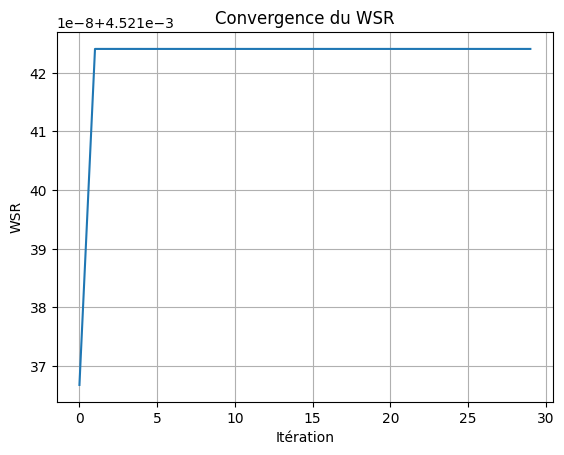

In [478]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(wsr_values)
plt.xlabel("Itération")
plt.ylabel("WSR")
plt.title("Convergence du WSR")
plt.grid()
plt.show()

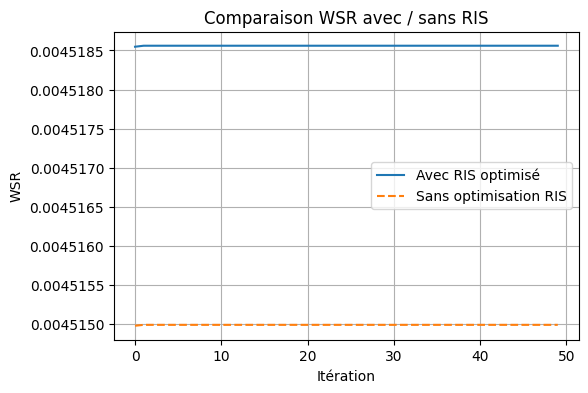

In [479]:
def run_simulation(optimize_theta=True):

    theta = np.exp(1j * 2*np.pi*np.random.rand(N))
    W = (np.random.randn(M, K) + 1j*np.random.randn(M, K)) / np.sqrt(2)
    W = W / np.linalg.norm(W)

    wsr_values = []
    d_bar = None

    for it in range(n_iter):

        hk = compute_hk(hd, Hr, theta)

        # update W
        W = update_W(hk, W)
        W = W / (np.linalg.norm(W) + 1e-9) # pourquoi ?
        #W = W / (np.linalg.norm(W))*np.sqrt(P_T)
 

        # a, b
        a, b = compute_a_b(Hr, hd, W)

        # avec ou sans optimisation RIS
        if optimize_theta:
            theta, d_bar = rcg_iteration(theta, a, b, d_bar)

        # nouveau canal
        hk = compute_hk(hd, Hr, theta)

        # WSR
        wsr = compute_wsr(hk, W)
        wsr_values.append(wsr)

    return wsr_values

n_iter = 50

wsr_with_ris = run_simulation(optimize_theta=True)
wsr_without_ris = run_simulation(optimize_theta=False)


import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(wsr_with_ris, label="Avec RIS optimisé")
plt.plot(wsr_without_ris, label="Sans optimisation RIS", linestyle='--')

plt.xlabel("Itération")
plt.ylabel("WSR")
plt.title("Comparaison WSR avec / sans RIS")
plt.legend()
plt.grid()

plt.show()